In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Dataset paths
TRAIN_DIR = '/kaggle/input/brain-tumor-mri-dataset/Training'
TEST_DIR = '/kaggle/input/brain-tumor-mri-dataset/Testing'

print('Libraries imported successfully')
print(f'Training directory: {TRAIN_DIR}')
print(f'Testing directory: {TEST_DIR}')

Libraries imported successfully
Training directory: /kaggle/input/brain-tumor-mri-dataset/Training
Testing directory: /kaggle/input/brain-tumor-mri-dataset/Testing


In [2]:
def count_images_in_directory(base_dir):
    """
    Count number of images in each class folder
    """
    class_counts = {}
    
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(image_files)
    
    return class_counts

# Count images in training set
train_counts = count_images_in_directory(TRAIN_DIR)
print('Training Set Distribution:')
for class_name, count in sorted(train_counts.items()):
    print(f'{class_name}: {count} images')

print()

# Count images in testing set
test_counts = count_images_in_directory(TEST_DIR)
print('Testing Set Distribution:')
for class_name, count in sorted(test_counts.items()):
    print(f'{class_name}: {count} images')

print()
print(f'Total training images: {sum(train_counts.values())}')
print(f'Total testing images: {sum(test_counts.values())}')

Training Set Distribution:
glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images

Testing Set Distribution:
glioma: 300 images
meningioma: 306 images
notumor: 405 images
pituitary: 300 images

Total training images: 5712
Total testing images: 1311


In [3]:
# Create dataframes for easier plotting
train_df = pd.DataFrame(list(train_counts.items()), columns=['Class', 'Count'])
train_df['Split'] = 'Training'

test_df = pd.DataFrame(list(test_counts.items()), columns=['Class', 'Count'])
test_df['Split'] = 'Testing'

# Combine both
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Calculate total per class
total_per_class = combined_df.groupby('Class')['Count'].sum().reset_index()
total_per_class.columns = ['Class', 'Total Count']

print('Total Images Per Class:')
print(total_per_class.to_string(index=False))

Total Images Per Class:
     Class  Total Count
    glioma         1621
meningioma         1645
   notumor         2000
 pituitary         1757


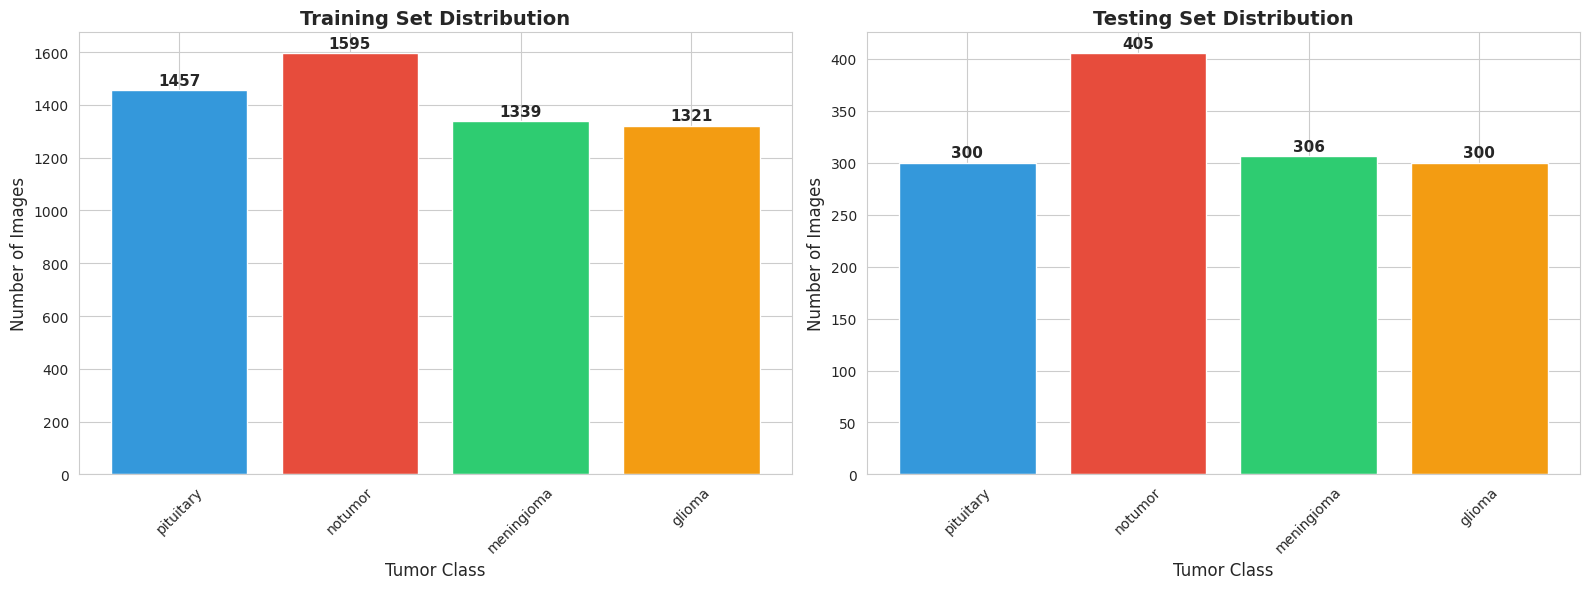

In [4]:
# Plot training set distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set bar plot
axes[0].bar(train_df['Class'], train_df['Count'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_xlabel('Tumor Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (class_name, count) in enumerate(zip(train_df['Class'], train_df['Count'])):
    axes[0].text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')

# Testing set bar plot
axes[1].bar(test_df['Class'], test_df['Count'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_xlabel('Tumor Class', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Testing Set Distribution', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Add count labels on bars
for i, (class_name, count) in enumerate(zip(test_df['Class'], test_df['Count'])):
    axes[1].text(i, count + 5, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Calculate imbalance in training set
max_train_count = max(train_counts.values())
min_train_count = min(train_counts.values())

print('Training Set Imbalance Analysis:')
print(f'Largest class: {max_train_count} images')
print(f'Smallest class: {min_train_count} images')
print(f'Imbalance ratio: {max_train_count / min_train_count:.2f}x')
print()

# Calculate percentage distribution
print('Training Set Percentage Distribution:')
total_train = sum(train_counts.values())
for class_name, count in sorted(train_counts.items()):
    percentage = (count / total_train) * 100
    print(f'{class_name}: {percentage:.2f}%')

Training Set Imbalance Analysis:
Largest class: 1595 images
Smallest class: 1321 images
Imbalance ratio: 1.21x

Training Set Percentage Distribution:
glioma: 23.13%
meningioma: 23.44%
notumor: 27.92%
pituitary: 25.51%


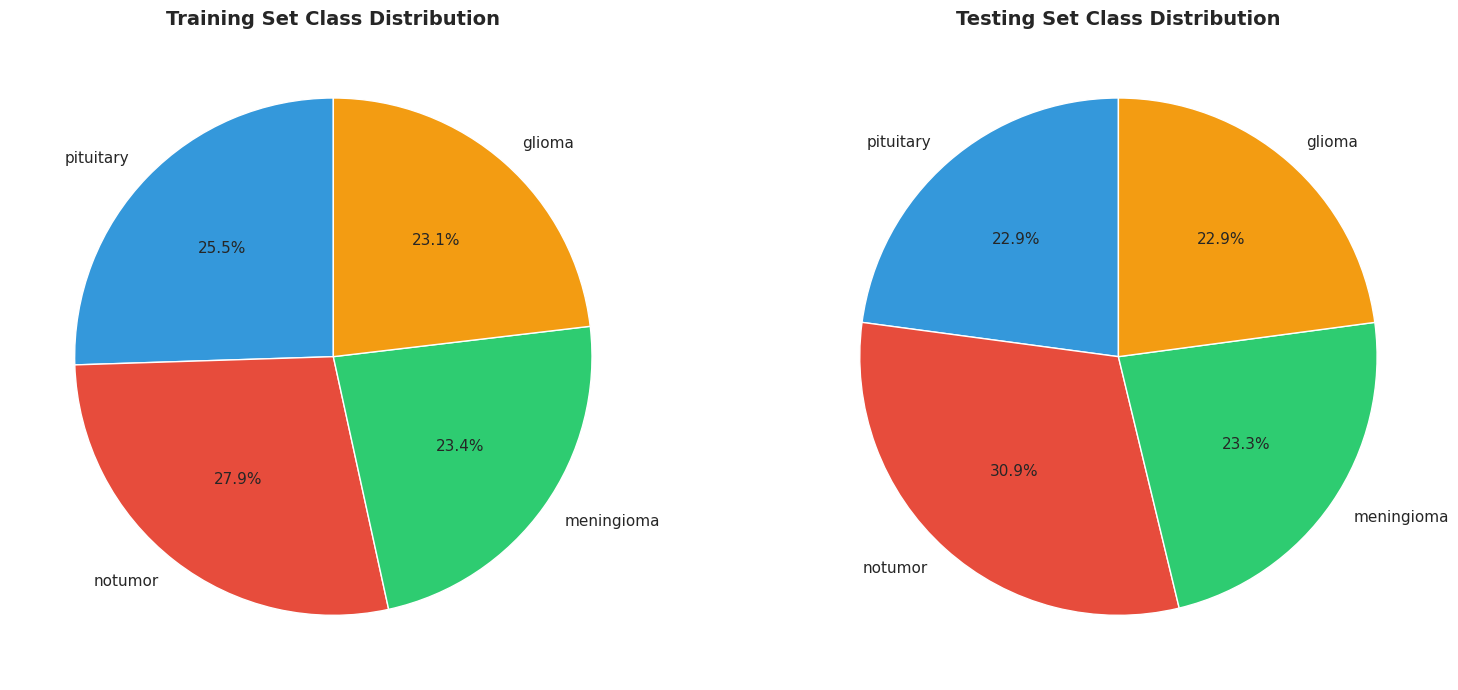

In [6]:
# Create pie chart for training distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Training set pie chart
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
axes[0].pie(train_df['Count'], labels=train_df['Class'], autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')

# Testing set pie chart
axes[1].pie(test_df['Count'], labels=test_df['Class'], autopct='%1.1f%%', 
            startangle=90, colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Testing Set Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
def get_image_dimensions(base_dir, sample_size=50):
    """
    Analyze dimensions of sample images from each class
    """
    dimensions_data = []
    
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Sample images
            sample_files = image_files[:min(sample_size, len(image_files))]
            
            for img_file in sample_files:
                img_path = os.path.join(class_path, img_file)
                try:
                    img = Image.open(img_path)
                    width, height = img.size
                    dimensions_data.append({
                        'Class': class_name,
                        'Width': width,
                        'Height': height,
                        'Aspect_Ratio': width / height
                    })
                except:
                    pass
    
    return pd.DataFrame(dimensions_data)

# Analyze image dimensions
print('Analyzing image dimensions from training set...')
dimensions_df = get_image_dimensions(TRAIN_DIR, sample_size=50)

print('Image Dimension Statistics:')
print(dimensions_df.groupby('Class')[['Width', 'Height']].describe())

Analyzing image dimensions from training set...
Image Dimension Statistics:
           Width                                                           \
           count    mean         std    min     25%    50%    75%     max   
Class                                                                       
glioma      50.0  512.00    0.000000  512.0  512.00  512.0  512.0   512.0   
meningioma  50.0  508.32   32.627421  286.0  512.00  512.0  512.0   554.0   
notumor     50.0  358.42  198.730880  173.0  208.25  229.5  540.5   785.0   
pituitary   50.0  518.82  132.199245  256.0  512.00  512.0  512.0  1365.0   

           Height                                                          
            count    mean         std    min    25%    50%    75%     max  
Class                                                                      
glioma       50.0  512.00    0.000000  512.0  512.0  512.0  512.0   512.0  
meningioma   50.0  509.72   22.964071  356.0  512.0  512.0  512.0   554.0  
notu

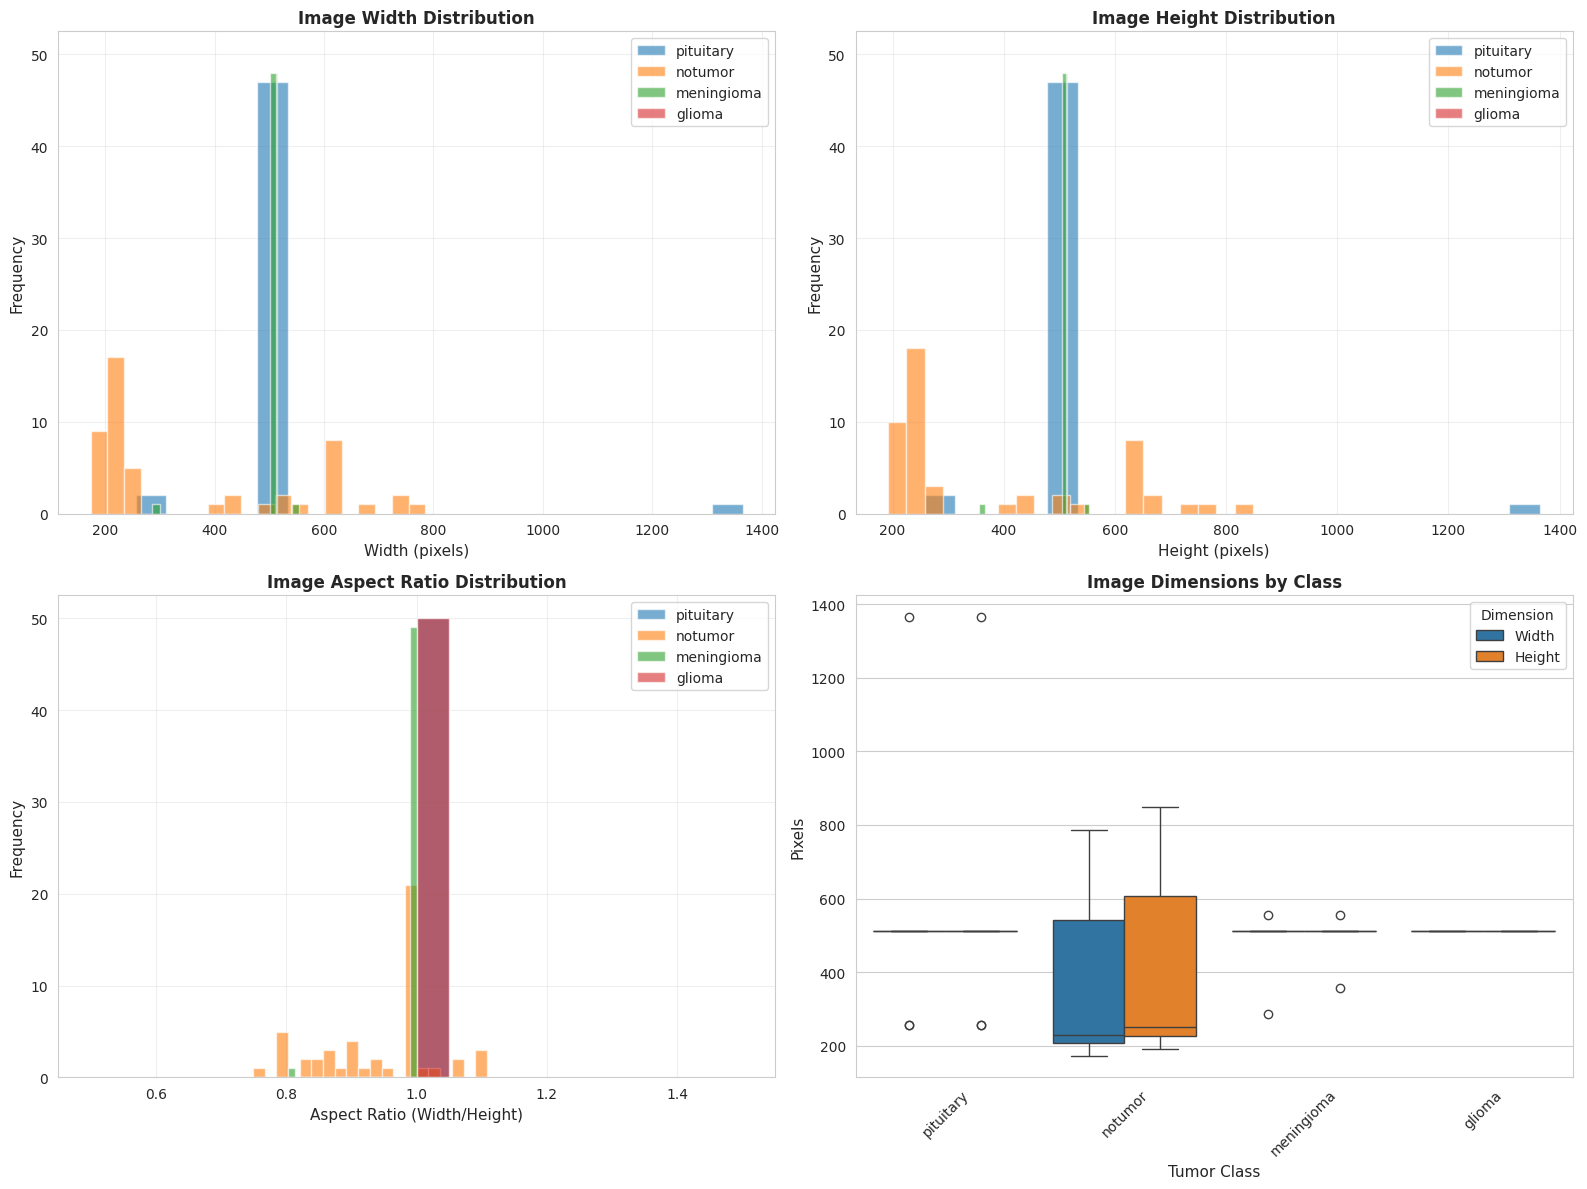

In [8]:
# Plot dimension distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Width distribution
for class_name in dimensions_df['Class'].unique():
    class_data = dimensions_df[dimensions_df['Class'] == class_name]
    axes[0, 0].hist(class_data['Width'], alpha=0.6, label=class_name, bins=20)
axes[0, 0].set_xlabel('Width (pixels)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Height distribution
for class_name in dimensions_df['Class'].unique():
    class_data = dimensions_df[dimensions_df['Class'] == class_name]
    axes[0, 1].hist(class_data['Height'], alpha=0.6, label=class_name, bins=20)
axes[0, 1].set_xlabel('Height (pixels)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Aspect ratio distribution
for class_name in dimensions_df['Class'].unique():
    class_data = dimensions_df[dimensions_df['Class'] == class_name]
    axes[1, 0].hist(class_data['Aspect_Ratio'], alpha=0.6, label=class_name, bins=20)
axes[1, 0].set_xlabel('Aspect Ratio (Width/Height)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Image Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Box plot for dimensions
dimension_data = []
for class_name in dimensions_df['Class'].unique():
    class_data = dimensions_df[dimensions_df['Class'] == class_name]
    for _, row in class_data.iterrows():
        dimension_data.append({'Class': class_name, 'Dimension': 'Width', 'Value': row['Width']})
        dimension_data.append({'Class': class_name, 'Dimension': 'Height', 'Value': row['Height']})

dimension_plot_df = pd.DataFrame(dimension_data)
sns.boxplot(x='Class', y='Value', hue='Dimension', data=dimension_plot_df, ax=axes[1, 1])
axes[1, 1].set_xlabel('Tumor Class', fontsize=11)
axes[1, 1].set_ylabel('Pixels', fontsize=11)
axes[1, 1].set_title('Image Dimensions by Class', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('image_dimensions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Displaying sample images from training set...


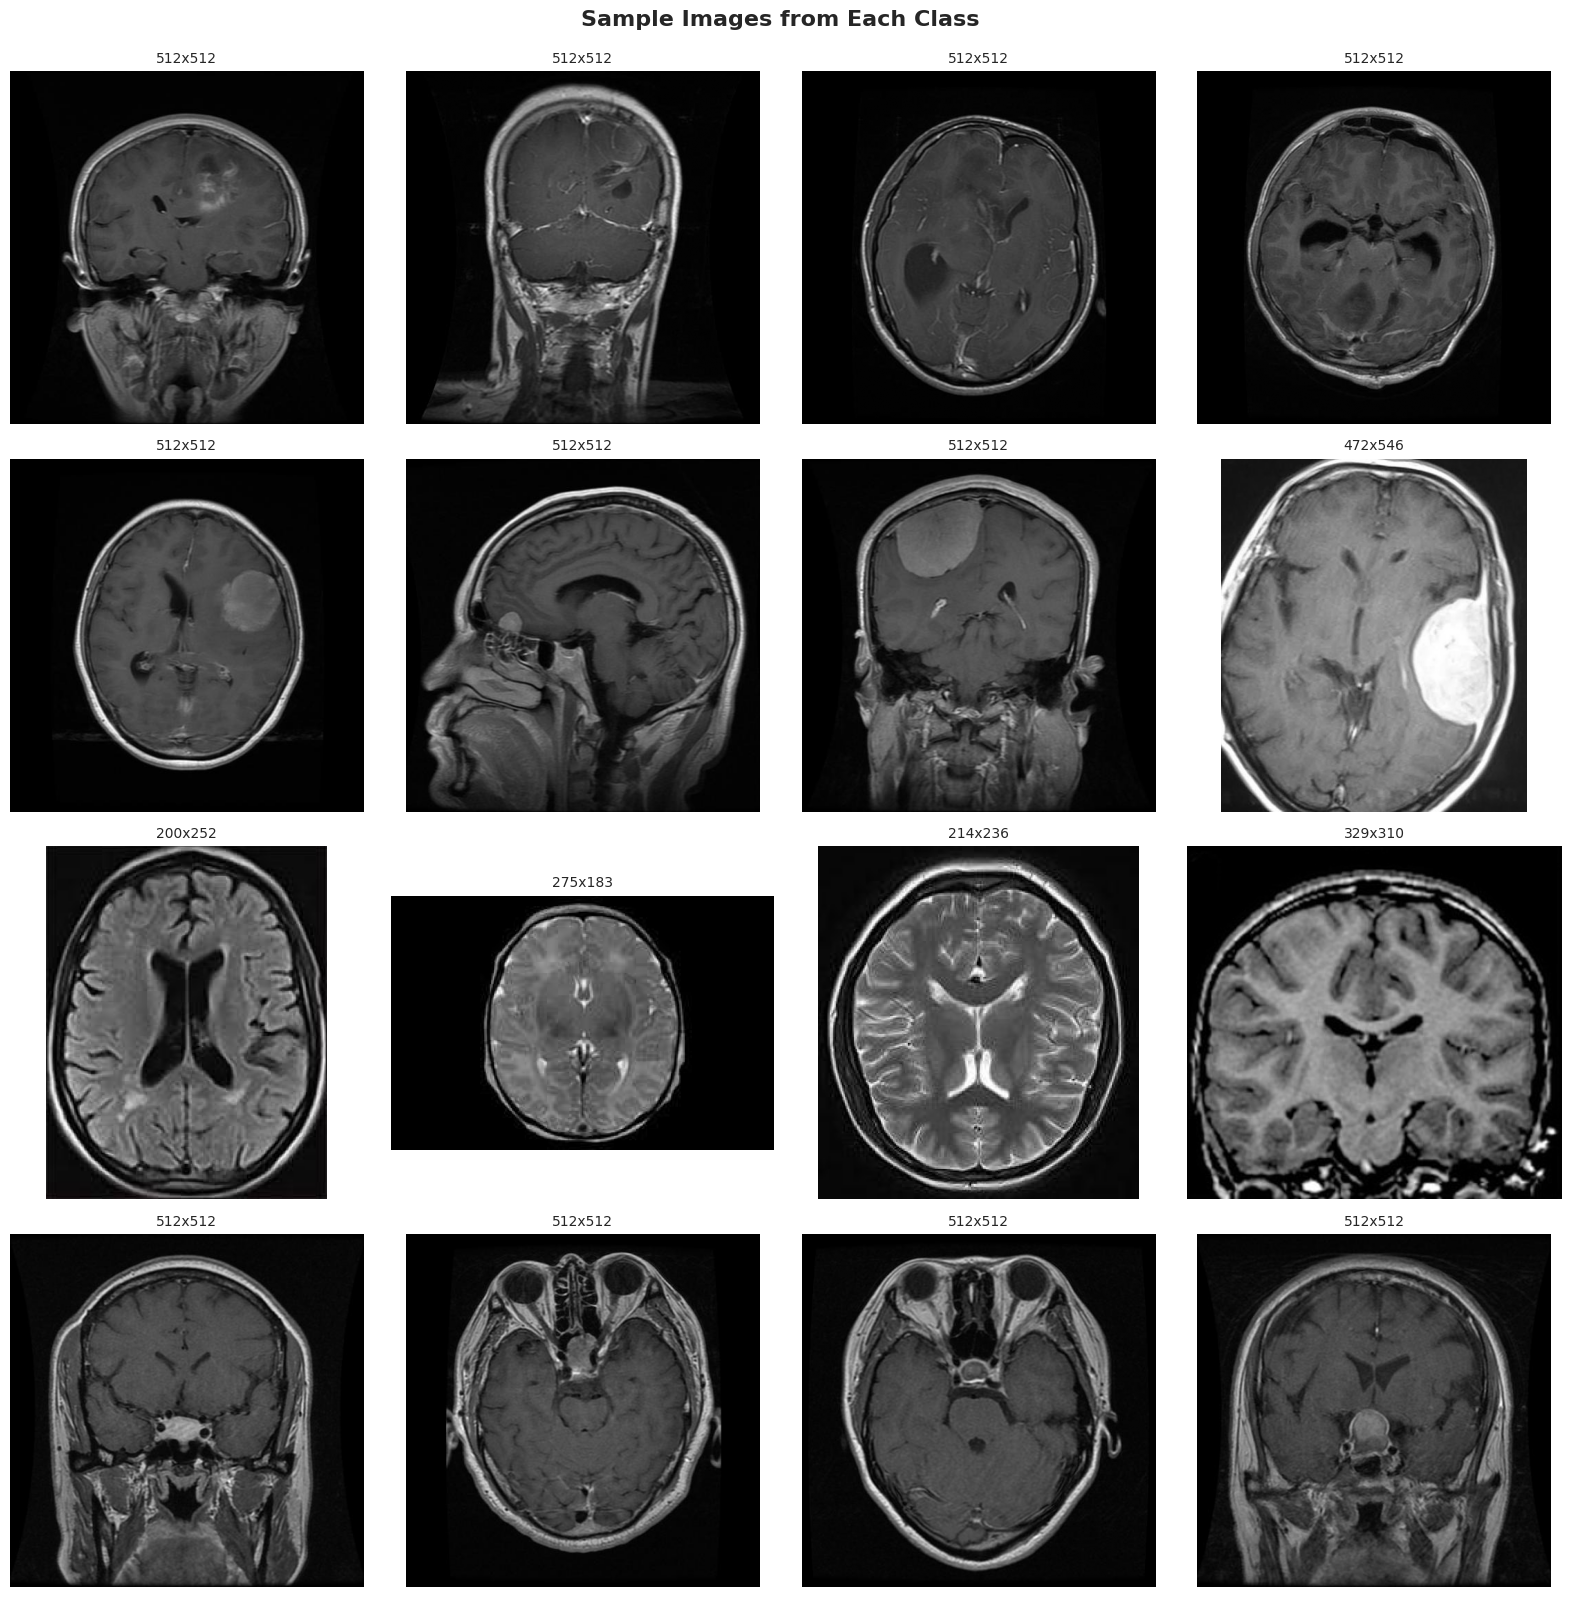

In [9]:
def display_sample_images(base_dir, samples_per_class=4):
    """
    Display sample images from each class
    """
    class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
    
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(16, len(class_names) * 4))
    
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(base_dir, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Select random samples
        sample_files = np.random.choice(image_files, min(samples_per_class, len(image_files)), replace=False)
        
        for j, img_file in enumerate(sample_files):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path)
            
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].set_ylabel(class_name, fontsize=12, fontweight='bold', rotation=90, labelpad=10)
            
            axes[i, j].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=10)
    
    plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('sample_images_per_class.png', dpi=300, bbox_inches='tight')
    plt.show()

# Display sample images
print('Displaying sample images from training set...')
display_sample_images(TRAIN_DIR, samples_per_class=4)

In [10]:
def analyze_image_intensity(base_dir, sample_size=30):
    """
    Analyze pixel intensity statistics for each class
    """
    intensity_data = []
    
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            sample_files = image_files[:min(sample_size, len(image_files))]
            
            for img_file in sample_files:
                img_path = os.path.join(class_path, img_file)
                try:
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        intensity_data.append({
                            'Class': class_name,
                            'Mean_Intensity': np.mean(img),
                            'Std_Intensity': np.std(img),
                            'Min_Intensity': np.min(img),
                            'Max_Intensity': np.max(img)
                        })
                except:
                    pass
    
    return pd.DataFrame(intensity_data)

# Analyze intensity statistics
print('Analyzing pixel intensity statistics...')
intensity_df = analyze_image_intensity(TRAIN_DIR, sample_size=30)

print('Pixel Intensity Statistics by Class:')
print(intensity_df.groupby('Class')['Mean_Intensity'].describe())

Analyzing pixel intensity statistics...
Pixel Intensity Statistics by Class:
            count       mean        std        min        25%        50%  \
Class                                                                      
glioma       30.0  35.117778  10.609765  21.749031  26.790645  32.817835   
meningioma   30.0  40.181745   8.093767  27.728649  33.477022  40.664858   
notumor      30.0  63.509292  22.130821  26.407525  50.230874  57.843392   
pituitary    30.0  51.116968   8.249138  30.329659  47.568374  50.373283   

                  75%         max  
Class                              
glioma      40.114151   68.363167  
meningioma  43.193461   62.938919  
notumor     80.839586  112.297760  
pituitary   54.545841   70.531685  


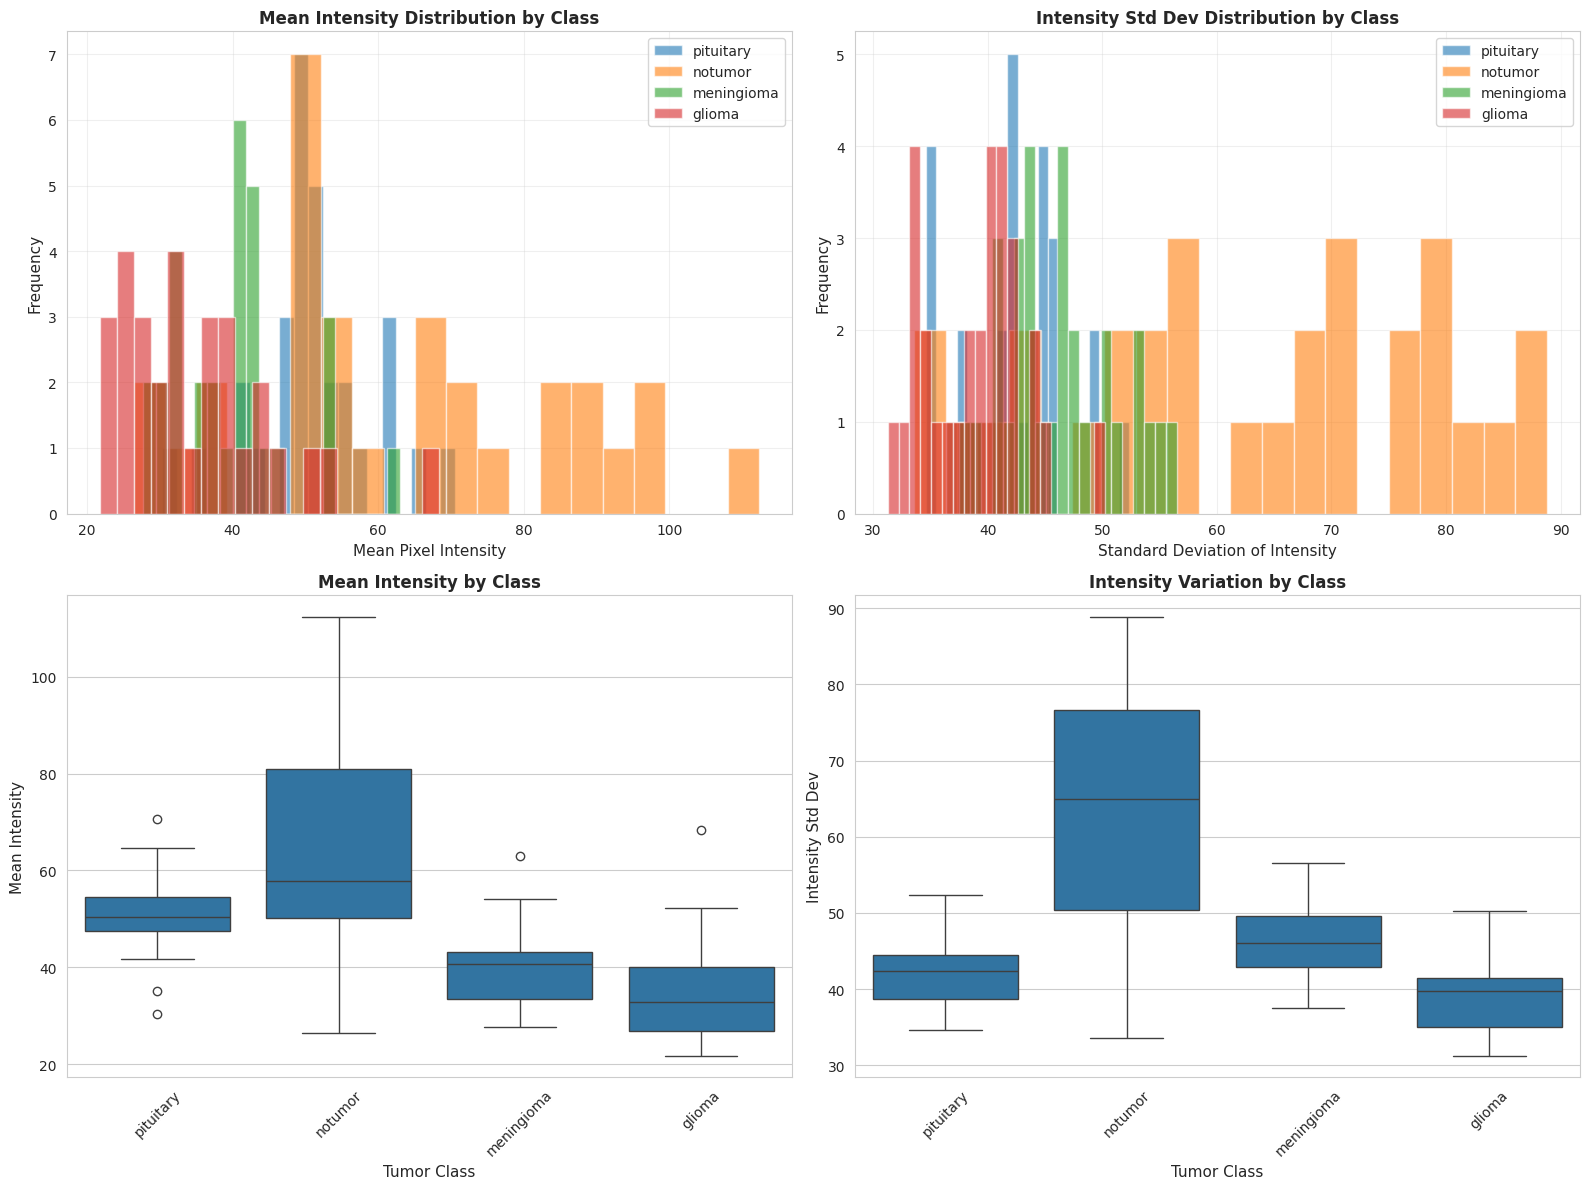

In [11]:
# Plot intensity distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mean intensity distribution
for class_name in intensity_df['Class'].unique():
    class_data = intensity_df[intensity_df['Class'] == class_name]
    axes[0, 0].hist(class_data['Mean_Intensity'], alpha=0.6, label=class_name, bins=20)
axes[0, 0].set_xlabel('Mean Pixel Intensity', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Mean Intensity Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Standard deviation distribution
for class_name in intensity_df['Class'].unique():
    class_data = intensity_df[intensity_df['Class'] == class_name]
    axes[0, 1].hist(class_data['Std_Intensity'], alpha=0.6, label=class_name, bins=20)
axes[0, 1].set_xlabel('Standard Deviation of Intensity', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Intensity Std Dev Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plot for mean intensity
sns.boxplot(x='Class', y='Mean_Intensity', data=intensity_df, ax=axes[1, 0])
axes[1, 0].set_xlabel('Tumor Class', fontsize=11)
axes[1, 0].set_ylabel('Mean Intensity', fontsize=11)
axes[1, 0].set_title('Mean Intensity by Class', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Box plot for intensity std dev
sns.boxplot(x='Class', y='Std_Intensity', data=intensity_df, ax=axes[1, 1])
axes[1, 1].set_xlabel('Tumor Class', fontsize=11)
axes[1, 1].set_ylabel('Intensity Std Dev', fontsize=11)
axes[1, 1].set_title('Intensity Variation by Class', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('intensity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Create comprehensive summary table
summary_data = []

for class_name in sorted(train_counts.keys()):
    train_count = train_counts[class_name]
    test_count = test_counts[class_name]
    total_count = train_count + test_count
    train_percentage = (train_count / sum(train_counts.values())) * 100
    
    summary_data.append({
        'Class': class_name,
        'Training Images': train_count,
        'Testing Images': test_count,
        'Total Images': total_count,
        'Training %': f'{train_percentage:.2f}%'
    })

summary_df = pd.DataFrame(summary_data)

print('Dataset Summary Statistics:')
print(summary_df.to_string(index=False))
print()

# Save summary to CSV
summary_df.to_csv('dataset_summary.csv', index=False)
print('Summary statistics saved to dataset_summary.csv')

Dataset Summary Statistics:
     Class  Training Images  Testing Images  Total Images Training %
    glioma             1321             300          1621     23.13%
meningioma             1339             306          1645     23.44%
   notumor             1595             405          2000     27.92%
 pituitary             1457             300          1757     25.51%

Summary statistics saved to dataset_summary.csv


In [13]:
# Calculate imbalance metrics
train_counts_sorted = sorted(train_counts.items(), key=lambda x: x[1])
min_class = train_counts_sorted[0]
max_class = train_counts_sorted[-1]

print('Class Imbalance Analysis:')
print(f'Most represented class: {max_class[0]} with {max_class[1]} images')
print(f'Least represented class: {min_class[0]} with {min_class[1]} images')
print(f'Imbalance factor: {max_class[1] / min_class[1]:.2f}x')
print()

# Calculate how many augmentations needed for balancing
print('Augmentation Requirements for Balancing:')
target_count = max_class[1]
for class_name, count in train_counts_sorted:
    needed = target_count - count
    multiplier = target_count / count
    print(f'{class_name}: Need {needed} more images (augment by {multiplier:.2f}x)')

Class Imbalance Analysis:
Most represented class: notumor with 1595 images
Least represented class: glioma with 1321 images
Imbalance factor: 1.21x

Augmentation Requirements for Balancing:
glioma: Need 274 more images (augment by 1.21x)
meningioma: Need 256 more images (augment by 1.19x)
pituitary: Need 138 more images (augment by 1.09x)
notumor: Need 0 more images (augment by 1.00x)


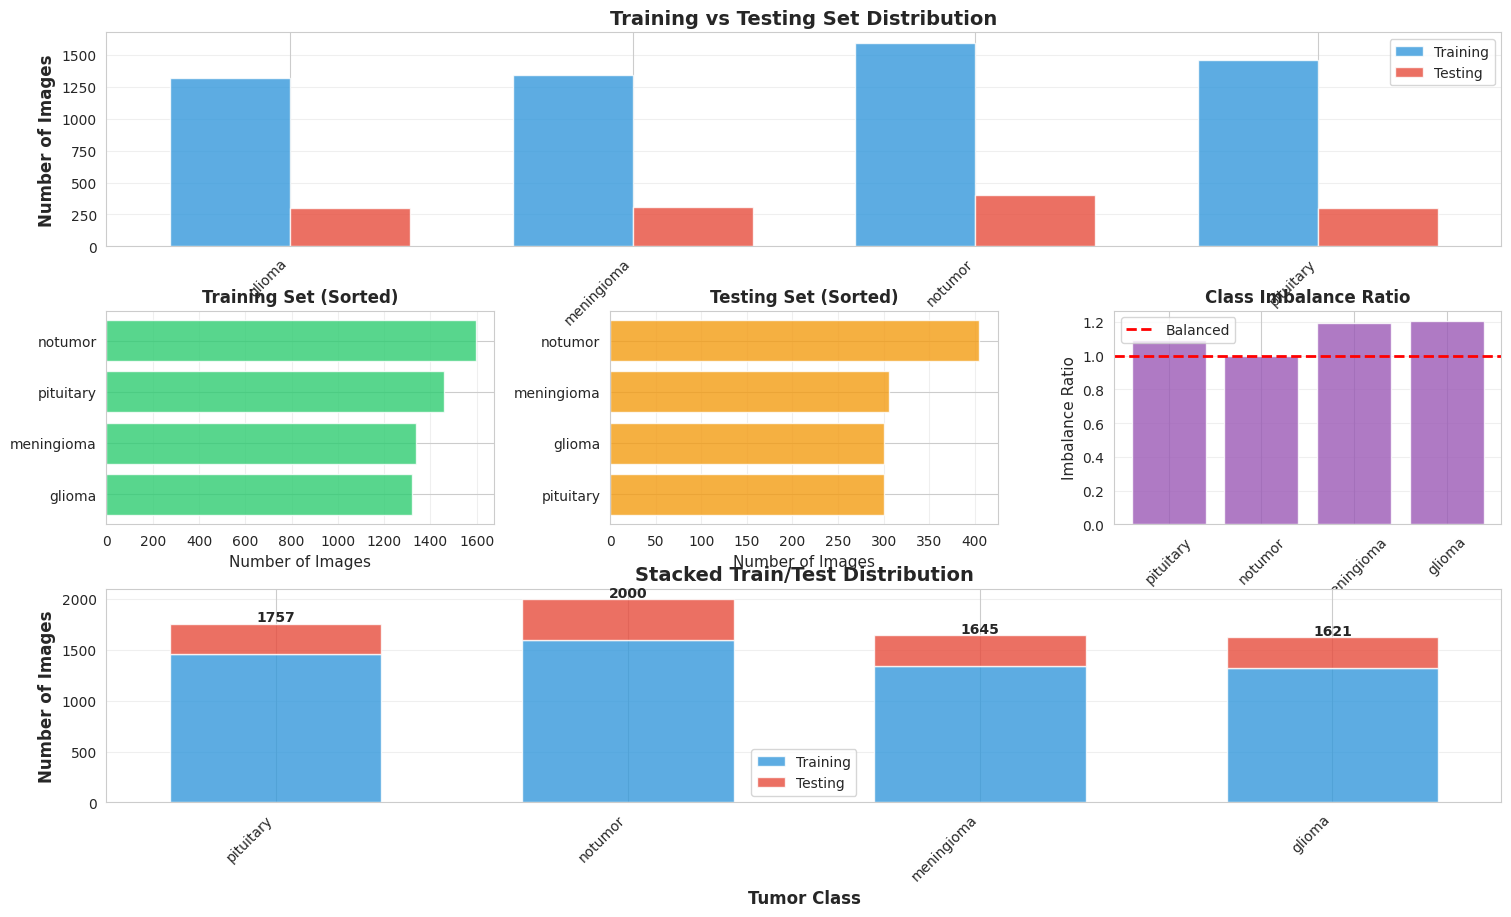

EDA complete! All visualizations saved.


In [14]:
# Create final summary visualization
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Combined train and test distribution
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(len(train_counts))
width = 0.35
ax1.bar(x_pos - width/2, [train_counts[c] for c in sorted(train_counts.keys())], 
        width, label='Training', color='#3498db', alpha=0.8)
ax1.bar(x_pos + width/2, [test_counts[c] for c in sorted(test_counts.keys())], 
        width, label='Testing', color='#e74c3c', alpha=0.8)
ax1.set_xlabel('Tumor Class', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Testing Set Distribution', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(sorted(train_counts.keys()), rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Training set imbalance visualization
ax2 = fig.add_subplot(gs[1, 0])
classes_sorted = sorted(train_counts.items(), key=lambda x: x[1])
y_pos = np.arange(len(classes_sorted))
ax2.barh(y_pos, [c[1] for c in classes_sorted], color='#2ecc71', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([c[0] for c in classes_sorted])
ax2.set_xlabel('Number of Images', fontsize=11)
ax2.set_title('Training Set (Sorted)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Testing set distribution
ax3 = fig.add_subplot(gs[1, 1])
test_sorted = sorted(test_counts.items(), key=lambda x: x[1])
y_pos = np.arange(len(test_sorted))
ax3.barh(y_pos, [c[1] for c in test_sorted], color='#f39c12', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([c[0] for c in test_sorted])
ax3.set_xlabel('Number of Images', fontsize=11)
ax3.set_title('Testing Set (Sorted)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Imbalance ratio visualization
ax4 = fig.add_subplot(gs[1, 2])
imbalance_ratios = {c: max_class[1] / train_counts[c] for c in train_counts.keys()}
ax4.bar(imbalance_ratios.keys(), imbalance_ratios.values(), color='#9b59b6', alpha=0.8)
ax4.set_xlabel('Tumor Class', fontsize=11)
ax4.set_ylabel('Imbalance Ratio', fontsize=11)
ax4.set_title('Class Imbalance Ratio', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')
ax4.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Balanced')
ax4.legend()

# Dataset split visualization
ax5 = fig.add_subplot(gs[2, :])
categories = list(train_counts.keys())
train_vals = [train_counts[c] for c in categories]
test_vals = [test_counts[c] for c in categories]

x = np.arange(len(categories))
width = 0.6

p1 = ax5.bar(x, train_vals, width, label='Training', color='#3498db', alpha=0.8)
p2 = ax5.bar(x, test_vals, width, bottom=train_vals, label='Testing', color='#e74c3c', alpha=0.8)

ax5.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax5.set_xlabel('Tumor Class', fontsize=12, fontweight='bold')
ax5.set_title('Stacked Train/Test Distribution', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(categories, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# Add total count labels on stacked bars
for i, (train_val, test_val) in enumerate(zip(train_vals, test_vals)):
    total = train_val + test_val
    ax5.text(i, total + 20, str(total), ha='center', fontsize=10, fontweight='bold')

plt.savefig('complete_eda_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print('EDA complete! All visualizations saved.')